In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle as pk 

In [2]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_greg = ['#9A0EEA','#BF77F6','#030AA7','#0165FC','#39AD48','#F97306','#F7022A']

In [3]:
ps_exp_res = pk.load(open('../data/gif_fttps_res.p','rb'))
ps_exp_res[0] = ps_exp_res[1]*1.01

PSD_res = 1-ps_exp_res
PSD_res[len(PSD_res)//2+2:] = 0.039 + 0.02*np.random.rand(len(PSD_res)//2-2)
PSD_res[6] = 0.045
PSD_res[10] = 0.12

ps_exp_res = 1-PSD_res
K = len(ps_exp_res)

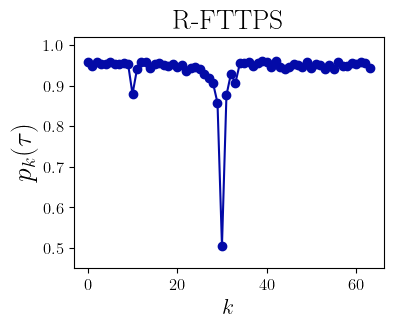

In [4]:
fig = plt.figure(dpi=100, figsize=(4,3))

kk = np.arange(K)

plt.title('R-FTTPS', fontsize=20)
plt.plot(np.arange(K), ps_exp_res, marker='o', color=colors_greg[2], label='Experiment')

plt.ylabel(r'$p_k(\tau)$', fontsize=20)
plt.xlabel(r'$k$', fontsize=16)  
plt.ylim(0.45, 1.02)
plt.tick_params(axis='both', which='major', labelsize=12)
# plt.legend(frameon=False, fontsize=14, title_fontsize=16)

plt.show()

# Schwarma

In [5]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

In [6]:
num_FTTPS = K
N = num_FTTPS*2
worN = 8192
Phi, PhiRecon, num_gates = get_FTTS_FFs(N,worN=worN)
Phi = Phi.astype(np.float32)
num_gates = num_gates.astype(np.float32)

In [34]:
print("a  b  q   AIC")
fit_qs = []
for a_len in range(1,6):
    for b_len in range(1,6):
        learner = ZDephasingFFLearner(b_len,a_len)
        fit_q = learner.fit(ps_exp_res, Phi, num_gates)
        AIC = learner.akaike_info_criterion(ps_exp_res, Phi, num_gates)
        print("%d %d %.7f %.2f" %(a_len, b_len, fit_q, AIC))
        fit_qs += [(a_len, b_len, fit_q, AIC)]

a  b  q   AIC
1 1 0.0034168 -93.29
1 2 0.0033159 -93.21
1 3 0.0030214 -97.16
1 4 0.0028968 -97.86
1 5 0.0026856 -100.70
2 1 0.0019614 -126.81
2 2 0.0033076 -91.37
2 3 0.0002475 -255.30
2 4 0.0002396 -255.37
2 5 0.0002557 -249.21
3 1 0.0015139 -141.39
3 2 0.0014273 -143.16
3 3 0.0004662 -212.77
3 4 0.0002666 -246.54
3 5 0.0003372 -229.51
4 1 0.0014960 -140.15
4 2 0.0014474 -140.26
4 3 0.0006390 -190.59
4 4 0.0006619 -186.34
4 5 0.0002376 -249.92
5 1 0.0011634 -154.24
5 2 0.0011070 -155.42
5 3 0.0005983 -192.81
5 4 0.0007660 -174.99
5 5 0.0003036 -232.22


In [35]:
q_opt = 1
for fit in fit_qs:
    if q_opt > fit[2]: 
        a_opt, b_opt, q_opt, AIC_opt = fit
print("Optimal values based on tf.model.eval:")
print("%d %d %.6f %.2f" %(a_opt, b_opt, q_opt, AIC_opt))

AIC_opt = 0
for fit in fit_qs:
    if AIC_opt > fit[3]: 
        a_opt, b_opt, q_opt, AIC_opt = fit
print("Optimal values based on AIC:")
print("%d %d %.6f %.2f" %(a_opt, b_opt, q_opt, AIC_opt))

Optimal values based on tf.model.eval:
4 5 0.000238 -249.92
Optimal values based on AIC:
2 4 0.000240 -255.37


In [7]:
a_opt, b_opt = 2,4
learner = ZDephasingFFLearner(b_opt,a_opt)
learner.fit(ps_exp_res, Phi, num_gates)

0.00011069115134887397

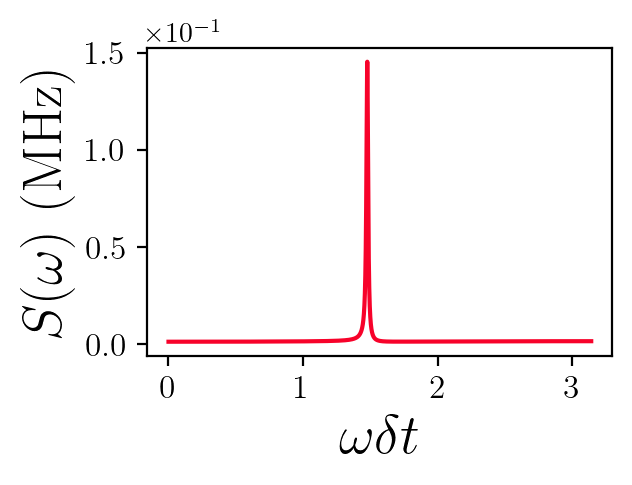

In [8]:
b_hat, a_hat = learner.convert_to_lfilter_form()
S = SimpleDephasingSchWARMAFier(b_hat,a_hat)
w, h_hat = si.freqz(b_hat,a_hat,worN = 2048*8, whole=False)

plt.figure(figsize=(3,2), dpi=200)

ww, PSD = S.psd(worN=worN)
plt.plot(ww,PSD, color=colors_greg[6])

plt.ylabel(r'$S(\omega)$ (MHz)', fontsize=20)
plt.xlabel(r'$\omega \delta t$', fontsize=20)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tick_params(labelsize=12)
plt.show()

In [9]:
b_hat, a_hat = learner.convert_to_lfilter_form()
S = SimpleDephasingSchWARMAFier(b_hat,a_hat)
w, h_hat = si.freqz(b_hat,a_hat,worN = 2048*8, whole=False)

p_k = []
ww, PSD = S.psd(worN=worN//2)
for k,FF in enumerate(Phi):
    chi = np.sum(FF[:worN//2]*PSD)*2
    p_k += [(1+np.exp(-chi))/2]

C:\Users\14432\AppData\Local\Temp\ipykernel_1820\2933447351.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


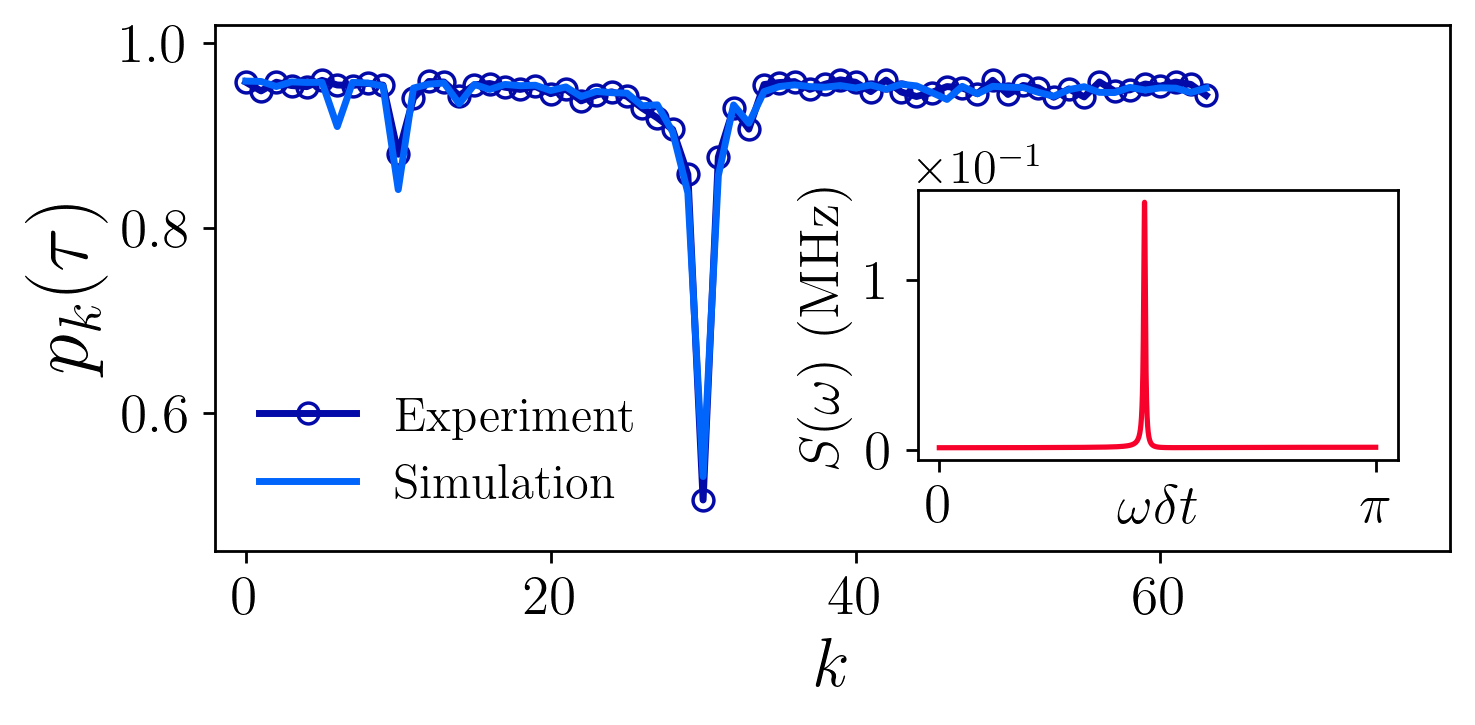

In [49]:
fig, ax = plt.subplots(figsize=(6,3), dpi=250)

ax.plot(kk, ps_exp_res, marker='o', mfc='none', lw=2, color=colors_greg[2], label='Experiment')
ax.plot(kk, p_k, marker='', color=colors_greg[3], label='Simulation', lw=2)

ax.set_ylabel(r'$p_k(\tau)$', fontsize=24)
ax.set_xlabel(r'$k$', fontsize=20)  
ax.set_ylim(0.45, 1.02)
ax.set_xlim(-2,79)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(frameon=False, fontsize=14, title_fontsize=16)

left, bottom, width, height = [0.62, 0.37, 0.32, 0.36]
ax2 = fig.add_axes([left, bottom, width, height])
ax2.plot(ww,PSD, color=colors_greg[6])
ax2.set_ylabel(r'$S(\omega)$ (MHz)', fontsize=16)
ax2.set_xlabel(r'$\omega \delta t$', fontsize=16, labelpad=-14)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.yaxis.get_offset_text().set_fontsize(14)
ax2.set_xticks([0,np.pi],['0','$\pi$'])
ax2.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig('figures/FTTPS_resonance.pdf')
plt.show()